In [1]:
# Cell 1 — Setup + data load: GC=F daily OHLCV + spot-gold benchmark (spec.json).
# Trading: yfinance GC=F (continuous front-month COMEX gold futures).
# Benchmark: ftmo_daily XAUUSD spot proxy — yfinance XAUUSD=X is currently unavailable.
# Calendar: NYSE business days; missing bars ffill last price (spec filter).
import pandas as pd
import yfinance as yf
from pathlib import Path
from backtest.data import DataPanel, FieldSpec

DATA_DIR = Path(r"C:\Users\User\backtest_engine\backtest_engine2\data")
GC_PATH = DATA_DIR / "tfg_gc_futures.parquet"
BM_PATH = DATA_DIR / "tfg_xauusd_benchmark.parquet"
START = "2005-01-01"
ASSET = "GC=F"
GC_CONTRACT_OZ = 100  # COMEX GC contract multiplier: 100 troy oz per contract

if GC_PATH.exists():
    gc = pd.read_parquet(GC_PATH)
    print(f"Loaded cached GC=F parquet: {gc.shape[0]} rows.")
else:
    raw = yf.download(ASSET, start=START, auto_adjust=True, progress=False)
    gc = pd.DataFrame({
        "open": raw["Open"][ASSET],
        "high": raw["High"][ASSET],
        "low": raw["Low"][ASSET],
        "close": raw["Close"][ASSET],
        "volume": raw["Volume"][ASSET],
    })
    gc.index = pd.to_datetime(gc.index).tz_localize(None)
    gc.index.name = "date"
    DATA_DIR.mkdir(exist_ok=True)
    gc.to_parquet(GC_PATH)
    print(f"Downloaded GC=F -> {GC_PATH.name}")

if BM_PATH.exists():
    benchmark = pd.read_parquet(BM_PATH).squeeze("columns")
    print(f"Loaded cached benchmark parquet: {len(benchmark)} rows.")
else:
    ftmo = pd.read_parquet(DATA_DIR / "ftmo_daily.parquet")
    ftmo["date"] = pd.to_datetime(ftmo["date"]).dt.tz_localize(None)
    benchmark = (
        ftmo.loc[ftmo["symbol"] == "XAUUSD", ["date", "close"]]
        .set_index("date")["close"]
        .sort_index()
    )
    benchmark = benchmark[benchmark.index >= pd.Timestamp(START)]
    benchmark.to_frame("XAUUSD").to_parquet(BM_PATH)
    print(f"Built XAUUSD spot benchmark from ftmo_daily -> {BM_PATH.name}")

# NYSE business-day grid; spec: carry forward last known price on gaps.
grid = pd.bdate_range(gc.index.min(), gc.index.max())
ohlcv = gc.reindex(grid).ffill()
prices = ohlcv[["close"]].rename(columns={"close": ASSET})
# yfinance GC=F volume is in CONTRACTS; engine ADV math (LiquidityCap, MarketImpact)
# computes volume × price, so scale to oz so that product = true notional.
# Feed still undercounts real CME activity (~150-250k contracts/day) — conservative.
volume = ohlcv[["volume"]].rename(columns={"volume": ASSET}) * GC_CONTRACT_OZ
features = {
    "open": ohlcv[["open"]].rename(columns={"open": ASSET}),
    "high": ohlcv[["high"]].rename(columns={"high": ASSET}),
    "low": ohlcv[["low"]].rename(columns={"low": ASSET}),
}
ffill_spec = FieldSpec(lag=0, missing="ffill")
specs = {name: ffill_spec for name in ["prices", "volume", "open", "high", "low"]}

panel = DataPanel(
    prices,
    volume=volume,
    features=features,
    specs=specs,
    check_outliers=True,
)
benchmark = benchmark.reindex(grid).ffill()

print(f"Bars:   {len(panel.dates)}")
print(f"Assets: {list(panel.assets_all)}")
print(f"Range:  {panel.dates[0].date()} -> {panel.dates[-1].date()}")
print(f"NaN fraction in prices: {prices.isna().mean().mean():.3%}")
print(f"Features: {panel.available_fields()}")
print(f"Benchmark (XAUUSD spot proxy) aligned: {benchmark.notna().mean():.1%} coverage")
print(f"Active sample window per spec: {START} -> {panel.dates[-1].date()} "
      f"(10y train precedes first 2015-01 OOS slice)")
prices.tail(3)

Loaded cached GC=F parquet: 5401 rows.
Loaded cached benchmark parquet: 6673 rows.
Bars:   5607
Assets: ['GC=F']
Range:  2005-01-03 -> 2026-06-30
NaN fraction in prices: 0.000%
Features: ['prices', 'volume', 'high', 'low', 'open']
Benchmark (XAUUSD spot proxy) aligned: 100.0% coverage
Active sample window per spec: 2005-01-01 -> 2026-06-30 (10y train precedes first 2015-01 OOS slice)


C:\Users\User\AppData\Local\Temp\ipykernel_18244\300582459.py:66: UserWarning: DataPanel: 17 bar(s) with |return - median| > 10.0*MAD detected.
  Top examples:
    2026-01-30 GC=F: ret=-11.37%, mad_score=21.3
    2013-04-15 GC=F: ret=-9.35%, mad_score=17.5
    2008-09-17 GC=F: ret=+9.03%, mad_score=16.8
    2009-03-19 GC=F: ret=+7.83%, mad_score=14.6
    2006-06-13 GC=F: ret=-7.30%, mad_score=13.7
  Verify these are real moves, not bad ticks. Pass check_outliers=False to silence.
  panel = DataPanel(


,GC=F
2026-06-26,4078.699951
2026-06-29,4022.300049
2026-06-30,4029.000000


In [2]:
# Cell 2 — Stage 2: Forecast-to-Fill gold trend strategy (spec.json).
# Paper sizing in generate_weights; house cap 1% via RiskConfig at apply_risk.
# T+1: compute target at t, return yesterday's target. De-risk rule C (spec §6.3).
import numpy as np
import pandas as pd
from backtest.risk import RiskConfig
from backtest.strategy import Strategy

ASSET = "GC=F"
MAX_POSITION = 0.01  # user policy: no single name above 1% of equity

# spec.json parameters (frozen defaults; λ / Kelly stats set in fit on train only)
P = dict(
    K=50,
    beta=0.6,
    pbull_act=0.52,
    pbear_halve=0.50,
    pbear_close=0.55,
    z_clip=3.0,
    atr_n=14,
    hard_atr=2.0,
    trail_atr=1.5,
    max_age=30,
    vol_ann=0.15,
    w_max=2.0,
    kelly_frac=0.40,
    baseline_frac=0.25,
    cost_rt=0.7e-4,
    eta=0.02,
    n_rt=1,
    tdays=252,
    train_years=10,
    vol_lam=0.94,  # variance EWMA (RiskMetrics standard, spec vol_ewma_window_days=20)
)


def _ema(series: np.ndarray, lam: float) -> np.ndarray:
    out = np.empty_like(series, dtype=float)
    out[0] = series[0]
    for i in range(1, len(series)):
        out[i] = lam * out[i - 1] + (1.0 - lam) * series[i]
    return out


def _true_range(h: np.ndarray, l: np.ndarray, c: np.ndarray) -> np.ndarray:
    tr = np.empty(len(c), dtype=float)
    tr[0] = h[0] - l[0]
    prev = c[:-1]
    tr[1:] = np.maximum(h[1:] - l[1:], np.maximum(np.abs(h[1:] - prev), np.abs(l[1:] - prev)))
    return tr


def _atr(h: np.ndarray, l: np.ndarray, c: np.ndarray, n: int) -> np.ndarray:
    tr = _true_range(h, l, c)
    out = np.full(len(c), np.nan)
    for i in range(n - 1, len(c)):
        out[i] = tr[i - n + 1 : i + 1].mean()
    return out


def _ewma_var(r: np.ndarray, lam: float, sigma2_0: float) -> np.ndarray:
    out = np.empty(len(r), dtype=float)
    out[0] = sigma2_0
    for i in range(1, len(r)):
        out[i] = lam * out[i - 1] + (1.0 - lam) * r[i - 1] ** 2
    return out


def _kelly_f(mu: float, sigma2: float, k: float, eta: float, n: int, kappa: float) -> float:
    if sigma2 <= 0 or mu <= n * k:
        return 0.0
    disc = 9.0 * eta**2 * n**3 + 16.0 * sigma2 * (mu - n * k)
    if disc < 0:
        return 0.0
    x = (-3.0 * eta * n**1.5 + np.sqrt(disc)) / (4.0 * sigma2)
    return kappa * (x**2)


def _signals(px: np.ndarray, hi: np.ndarray, lo: np.ndarray, lam: float, mu_tr: float,
             sig_tr: float, sigma2_0: float) -> dict:
    """Forward-only signals on arrays ending at t (inclusive). All PIT."""
    y = np.log(np.maximum(px, 1e-12))
    y_t = _ema(y, lam)
    dy = np.diff(y_t, prepend=y_t[0])
    z = (dy - mu_tr) / sig_tr if sig_tr > 0 else np.zeros_like(dy)
    z_bar = np.clip(z, -P["z_clip"], P["z_clip"])
    p_trend = (z_bar + P["z_clip"]) / (2.0 * P["z_clip"])
    m = np.zeros(len(px), dtype=float)
    if len(px) > P["K"]:
        m[P["K"] :] = (px[P["K"] :] / px[: -P["K"]] > 1.0).astype(float)
    p_bull = P["beta"] * p_trend + (1.0 - P["beta"]) * m
    p_bear = 1.0 - p_bull
    r = np.zeros(len(px))
    r[1:] = px[1:] / px[:-1] - 1.0
    sig2 = _ewma_var(r, P["vol_lam"], sigma2_0)  # spec: fixed RiskMetrics λ, not trend λ
    sig_next = np.sqrt(np.maximum(sig2, 1e-16))
    sig_star = P["vol_ann"] / np.sqrt(P["tdays"])
    w_vol = np.minimum(P["w_max"], sig_star / sig_next)
    conf = np.clip((p_bull - 0.5) / 0.5, 0.0, 1.0)
    w_conf = w_vol * conf
    atr = _atr(hi, lo, px, P["atr_n"])
    return dict(
        dy=dy, p_bull=p_bull, p_bear=p_bear, w_conf=w_conf, w_vol=w_vol, atr=atr, r=r,
    )


def _unit_returns(px: np.ndarray, hi: np.ndarray, lo: np.ndarray, lam: float,
                  mu_tr: float, sig_tr: float, sigma2_0: float) -> np.ndarray:
    """Train-only unit-notional return proxy for Kelly μ, σ (weight=1 on activation else 0)."""
    sig = _signals(px, hi, lo, lam, mu_tr, sig_tr, sigma2_0)
    act = (sig["p_bull"] >= P["pbull_act"]) & (sig["dy"] > 0)
    return np.where(act, 1.0, 0.0) * sig["r"]


class ForecastToFillGoldStrategy(Strategy):
    """Forecast-to-Fill gold trend+momentum (Singha et al.); FAST config."""
    rebalance_frequency = "daily"

    def __init__(
        self,
        max_position: float = MAX_POSITION,
        max_gross: float = 1.0,
        max_net: float = 1.0,
        vol_only: bool = False,
    ):
        self._vol_only = vol_only
        self.risk = RiskConfig(
            max_position=max_position,
            max_gross=max_gross,
            max_net=max_net,
            target_vol=None,
        )
        self._lam = 0.94
        self._mu_tr = self._sig_tr = 0.0
        self._mu_k = self._sigma2_k = 0.0
        self._sigma2_0 = 1e-6
        self._fitted = False
        # T+1 execution lag
        self._pending: pd.Series | None = None
        # open-trade state (post-fill position management)
        self._in_trade = False
        self._entry_px = self._peak_px = 0.0
        self._trade_age = 0

    def __repr__(self) -> str:
        mode = "vol_only" if self._vol_only else "full_kelly"
        return (
            f"ForecastToFillGoldStrategy({mode}, K={P['K']}, beta={P['beta']}, "
            f"max_position={self.risk.max_position}, w_max_paper={P['w_max']}, T+1=True)"
        )

    def required_data(self) -> dict:
        return {"prices": None, "volume": None, "open": None, "high": None, "low": None}

    def fit(self, data) -> None:
        # spec: μ_train/σ_train, λ and Kelly stats from the PRECEDING 10-YEAR window only.
        # Engine's train view is end-clipped, not start-clipped — trim here.
        px_s = data.prices[ASSET].dropna()
        cutoff = px_s.index[-1] - pd.DateOffset(years=P["train_years"])
        px_s = px_s[px_s.index >= cutoff]
        px = px_s.to_numpy()
        hi = data.feature("high")[ASSET].reindex(data.prices.index).ffill().reindex(px_s.index).to_numpy()
        lo = data.feature("low")[ASSET].reindex(data.prices.index).ffill().reindex(px_s.index).to_numpy()
        r = np.zeros(len(px))
        r[1:] = px[1:] / px[:-1] - 1.0
        self._sigma2_0 = float(np.var(r[1:])) if len(r) > 2 else 1e-8

        best_lam, best_sr = 0.94, -np.inf
        for lam in np.arange(0.88, 0.995, 0.01):
            y = np.log(np.maximum(px, 1e-12))
            y_t = _ema(y, lam)
            dy = np.diff(y_t, prepend=y_t[0])
            mu, sig = float(np.mean(dy)), float(np.std(dy, ddof=1))
            if sig <= 0:
                continue
            sig_d = _signals(px, hi, lo, lam, mu, sig, self._sigma2_0)
            act = (sig_d["p_bull"] >= P["pbull_act"]) & (sig_d["dy"] > 0)
            ut = np.where(act, sig_d["r"], 0.0)
            if np.std(ut) < 1e-12:
                continue
            sr = np.mean(ut) / np.std(ut) * np.sqrt(P["tdays"])
            if sr > best_sr:
                best_sr, best_lam = sr, float(lam)

        self._lam = best_lam
        y = np.log(np.maximum(px, 1e-12))
        y_t = _ema(y, self._lam)
        dy = np.diff(y_t, prepend=y_t[0])
        self._mu_tr = float(np.mean(dy))
        self._sig_tr = float(np.std(dy, ddof=1)) or 1e-8

        ut = _unit_returns(px, hi, lo, self._lam, self._mu_tr, self._sig_tr, self._sigma2_0)
        self._mu_k = float(np.mean(ut))
        self._sigma2_k = max(float(np.var(ut, ddof=1)), 1e-12) if len(ut) > 1 else 1e-12

        self._fitted = True
        self._pending = None
        self._in_trade = False
        self._trade_age = 0

    def _raw_target(self, data, t: pd.Timestamp) -> float:
        if not self._fitted:
            return 0.0
        idx = data.prices.index
        if t not in idx:
            return 0.0
        i = idx.get_loc(t)
        if i < max(P["K"], P["atr_n"], 20):
            return 0.0

        px = data.prices[ASSET].iloc[: i + 1].to_numpy()
        hi = data.feature("high")[ASSET].iloc[: i + 1].to_numpy()
        lo = data.feature("low")[ASSET].iloc[: i + 1].to_numpy()
        sig = _signals(px, hi, lo, self._lam, self._mu_tr, self._sig_tr, self._sigma2_0)
        j = -1
        c, atr = px[j], sig["atr"][j]
        p_bull, p_bear, dy = sig["p_bull"][j], sig["p_bear"][j], sig["dy"][j]
        w_conf = sig["w_conf"][j]
        w_vol = sig["w_vol"][j]

        f = _kelly_f(self._mu_k, self._sigma2_k, P["cost_rt"], P["eta"], P["n_rt"], P["kelly_frac"])
        if self._vol_only:
            target = min(P["w_max"], w_conf)
        else:
            if f < 1e-8:
                f = P["baseline_frac"] * w_vol
            target = min(P["w_max"], f * w_conf)

        # exit / de-risk rule C on open trade
        if self._in_trade:
            self._trade_age += 1
            self._peak_px = max(self._peak_px, c)
            exit_now = False
            if np.isfinite(atr):
                if c < self._entry_px - P["hard_atr"] * atr:
                    exit_now = True
                elif c < self._peak_px - P["trail_atr"] * atr:
                    exit_now = True
            if self._trade_age >= P["max_age"]:
                exit_now = True
            if p_bear > P["pbear_close"]:
                exit_now = True
                target = 0.0
            elif p_bear > P["pbear_halve"]:
                target *= 0.5
            if exit_now:
                self._in_trade = False
                self._trade_age = 0
                target = 0.0
        else:
            if (p_bull >= P["pbull_act"]) and (dy > 0) and target > 0:
                self._in_trade = True
                self._entry_px = self._peak_px = c
                self._trade_age = 0
            else:
                target = 0.0

        return float(max(0.0, target))

    def generate_weights(self, data, t: pd.Timestamp) -> pd.Series:
        raw = self._raw_target(data, t)
        pending = pd.Series({ASSET: raw})
        if self._pending is None:
            out = pd.Series(0.0, index=data.assets)
        else:
            out = self._pending.reindex(data.assets).fillna(0.0)
        self._pending = pending
        return out


strat = ForecastToFillGoldStrategy()
train_end = panel.dates[panel.dates <= "2014-12-31"][-1]
strat.fit(panel.as_of(train_end))
print(strat)
print(f"fit through {train_end.date()}: lam={strat._lam:.3f} mu_tr={strat._mu_tr:.2e} "
      f"sig_tr={strat._sig_tr:.2e} mu_k={strat._mu_k:.2e} sigma2_k={strat._sigma2_k:.2e}")
print(f"RiskConfig: max_position={strat.risk.max_position} | "
      f"max_gross={strat.risk.max_gross} max_net={strat.risk.max_net}")

oos = panel.dates[(panel.dates >= "2015-01-01") & (panel.dates < "2015-02-01")]
rows = []
for t in oos:
    view = panel.as_of(t)
    proposed = strat.generate_weights(view, t)
    state = {"drawdown": 0.0, "equity": 1e6, "positions": pd.Series(0.0, index=panel.assets_all),
             "cash": 1e6, "peak": 1e6}
    final = strat.apply_risk(proposed, state, view)
    rows.append((t.date(), float(proposed.get(ASSET, 0)), float(final.get(ASSET, 0)),
                 strat._in_trade, float(strat._pending.get(ASSET, 0) if strat._pending is not None else 0)))

diag = pd.DataFrame(rows, columns=["date", "exec_w", "after_risk", "in_trade", "next_pending"])
print("\nJan-2015 T+1 walk (exec_w = weight applied at close; next_pending = computed today for tomorrow):")
print(diag.to_string(index=False))
print(f"\nPaper raw pending max in window: {diag.next_pending.max():.4f} | "
      f"after 1% cap max: {diag.after_risk.max():.4f}")

ForecastToFillGoldStrategy(full_kelly, K=50, beta=0.6, max_position=0.01, w_max_paper=2.0, T+1=True)
fit through 2014-12-31: lam=0.880 mu_tr=3.92e-04 sig_tr=3.06e-03 mu_k=1.77e-03 sigma2_k=5.34e-05
RiskConfig: max_position=0.01 | max_gross=1.0 max_net=1.0



Jan-2015 T+1 walk (exec_w = weight applied at close; next_pending = computed today for tomorrow):
      date   exec_w  after_risk  in_trade  next_pending
2015-01-01 0.000000    0.000000     False      0.000000
2015-01-02 0.000000    0.000000     False      0.000000
2015-01-05 0.000000    0.000000     False      0.000000
2015-01-06 0.000000    0.000000     False      0.000000
2015-01-07 0.000000    0.000000     False      0.000000
2015-01-08 0.000000    0.000000      True      0.000487
2015-01-09 0.000487    0.000487      True      0.000546
2015-01-12 0.000546    0.000546      True      0.000663
2015-01-13 0.000663    0.000663      True      0.000634
2015-01-14 0.000634    0.000634      True      0.000627
2015-01-15 0.000627    0.000627      True      0.000847
2015-01-16 0.000847    0.000847      True      0.000783
2015-01-19 0.000783    0.000783      True      0.000743
2015-01-20 0.000743    0.000743      True      0.000838
2015-01-21 0.000838    0.000838      True      0.000772
2015-

In [3]:
# Cell 3 — Stage 3: costs + liquidity (spec.json §2.3).
# Linear k=0.7 bps round-trip -> 0.35 bps per trade leg (Commission).
# Sqrt impact: engine MarketImpact(k, kind="sqrt") approximates paper eta=0.02
# (different functional form — see mismatch note below).
import pandas as pd
from backtest.costs import Commission, MarketImpact, CompositeCostModel, LiquidityCap
from backtest.engine import Engine

RT_BPS = 0.7
LEG_BPS = RT_BPS / 2.0          # one rebalance leg = half a round trip
IMPACT_K = 2.0                    # sqrt-impact scale; paper eta=0.02 (not 1:1 with k)
ADV_LOOKBACK = 20

costs = CompositeCostModel([
    Commission(bps=LEG_BPS),
    MarketImpact(k=IMPACT_K, kind="sqrt", adv_lookback=ADV_LOOKBACK),
])
liq = LiquidityCap(cap_pct=0.10, adv_lookback=ADV_LOOKBACK)

print("Cost components:", [type(m).__name__ for m in costs.models])
print(f"  Commission: {LEG_BPS} bps/leg ({RT_BPS} bps round-trip)")
print(f"  MarketImpact: k={IMPACT_K}, kind=sqrt, adv_lookback={ADV_LOOKBACK}")
print(f"LiquidityCap: cap_pct={liq.cap_pct}, adv_lookback={liq.adv_lookback}")
print(f"Panel has volume: {panel.has_field('volume')}")

# Worked example: $10k rebalance on latest bar (<< 1% of $1M — typical here).
view = panel.as_of(panel.dates[-1])
px = float(view.prices[ASSET].iloc[-1])
vol_med = float(view.volume[ASSET].tail(ADV_LOOKBACK).median())
adv_usd = vol_med * px
trade = pd.Series({ASSET: 10_000.0})
comm = costs.models[0].trade_cost(trade, view)
impact = costs.models[1].trade_cost(trade, view)
ratio = 10_000.0 / adv_usd
print(f"\nSanity @ {view.t.date()}  GC=F close={px:,.0f}  "
      f"ADV~{adv_usd/1e9:.2f}B notional ({vol_med:,.0f} oz = {vol_med/GC_CONTRACT_OZ:,.0f} contracts)")
print(f"  $10k trade: commission=${comm:.2f}  impact=${impact:.2f}  "
      f"total=${comm + impact:.2f}  (participation={ratio:.2e})")

# Pre-flight: Engine must construct (LiquidityCap needs volume on panel).
Engine(panel, strat, costs=costs, liquidity=liq)
print("Engine(panel, strat, costs, liquidity) construction: OK")

Cost components: ['Commission', 'MarketImpact']
  Commission: 0.35 bps/leg (0.7 bps round-trip)
  MarketImpact: k=2.0, kind=sqrt, adv_lookback=20
LiquidityCap: cap_pct=0.1, adv_lookback=20
Panel has volume: True

Sanity @ 2026-06-30  GC=F close=4,029  ADV~0.50B notional (124,450 oz = 1,244 contracts)
  $10k trade: commission=$0.35  impact=$0.01  total=$0.36  (participation=1.99e-05)
Engine(panel, strat, costs, liquidity) construction: OK


In [4]:
# Cell 4 — Stage 4: single-path OOS sanity run (first 6m test slice per spec).
# Train: 2005-01-01 .. 2014-12-31 (10y). Test: 2015-01-01 .. 2015-06-30 (6m).
import numpy as np
from backtest.engine import Engine

train_dates = panel.dates[panel.dates <= "2014-12-31"]
test_dates = panel.dates[(panel.dates >= "2015-01-01") & (panel.dates <= "2015-06-30")]

strat_run = ForecastToFillGoldStrategy()  # fresh instance — reset T+1 / trade state
engine = Engine(panel, strat_run, costs=costs, liquidity=liq, initial_capital=1_000_000)
result = engine.run(train_dates=train_dates, test_dates=test_dates)

eq = result.equity_curve
ret = result.returns.dropna()
yrs = (eq.index[-1] - eq.index[0]).days / 365.25
ann_vol = ret.std() * np.sqrt(252)
sh = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else float("nan")
dd = (eq / eq.cummax() - 1).min()
active = (result.weights[ASSET].abs() > 1e-4).sum()

print(f"OOS window: {eq.index[0].date()} -> {eq.index[-1].date()} ({len(eq)} bars, {yrs:.2f}y)")
print(f"fit_called: {result.metadata.get('fit_called')} | rebalances: {result.metadata['n_rebalances']}")
print(f"fitted lam: {strat_run._lam:.3f}")
print(f"Final equity: ${eq.iloc[-1]:,.0f}  (P&L {(eq.iloc[-1] / 1e6 - 1):+.2%})")
print(f"Net Sharpe: {sh:+.2f} | ann vol {ann_vol:.2%} | maxDD {dd:.2%}")
print(f"Total costs: ${result.costs.sum():,.2f}  ({1e4 * result.costs.sum() / 1e6:.1f} bps on $1M)")
print(f"Max |weight|: {result.weights[ASSET].abs().max():.4f} | "
      f"mean |weight| active: {result.weights[ASSET].abs()[result.weights[ASSET].abs() > 1e-4].mean():.4f}")
print(f"Active days (|w|>0.01%): {active} / {len(eq)} ({100 * active / len(eq):.1f}%)")
print(f"Unfilled notional sum: ${result.unfilled.abs().sum().sum():,.0f}")

eq.tail(3)


OOS window: 2015-01-01 -> 2015-06-30 (129 bars, 0.49y)
fit_called: True | rebalances: 129
fitted lam: 0.880
Final equity: $999,974  (P&L -0.00%)
Net Sharpe: -0.90 | ann vol 0.01% | maxDD -0.01%
Total costs: $0.31  (0.0 bps on $1M)
Max |weight|: 0.0008 | mean |weight| active: 0.0006
Active days (|w|>0.01%): 31 / 129 (24.0%)
Unfilled notional sum: $0


2015-06-26    999974.333777
2015-06-29    999974.333777
2015-06-30    999974.333777
Freq: B, Name: equity, dtype: float64

In [5]:
# Cell 5 — Walk-forward: 10y train / 6m test, non-overlapping 6-month folds (spec).
# Each OOS day belongs to exactly one fold; refit every 6 months on trailing 10y.
# WalkForward splitter is single-split only — manual fold loop here (PROTOCOL §7).
import numpy as np
import pandas as pd
from backtest.engine import Engine
from backtest.metrics import compute_metrics

OOS_START = pd.Timestamp("2015-01-01")
OOS_END = pd.Timestamp("2025-10-31")
TRAIN_YEARS = 10
TEST_MONTHS = 6
CAPITAL = 1_000_000

fold_months = pd.date_range(OOS_START, OOS_END, freq="6MS")  # non-overlapping 6m folds
stitched_ret: dict = {}
fold_rows = []
total_costs = 0.0

for i, month in enumerate(fold_months):
    pos = panel.dates.searchsorted(month, side="left")
    if pos >= len(panel.dates):
        break
    ts = panel.dates[pos]
    if ts > OOS_END:
        break

    prior = panel.dates[panel.dates < ts]
    if len(prior) == 0:
        continue
    train_end = prior[-1]
    train_start = train_end - pd.DateOffset(years=TRAIN_YEARS)
    train_dates = panel.dates[(panel.dates >= train_start) & (panel.dates <= train_end)]
    test_end = min(ts + pd.DateOffset(months=TEST_MONTHS), OOS_END)
    test_dates = panel.dates[(panel.dates >= ts) & (panel.dates <= test_end)]
    if len(train_dates) < 252 * 5 or len(test_dates) < 10:
        continue

    strat_fold = ForecastToFillGoldStrategy()
    eng = Engine(panel, strat_fold, costs=costs, liquidity=liq, initial_capital=CAPITAL)
    res = eng.run(train_dates=train_dates, test_dates=test_dates)
    total_costs += float(res.costs.sum())
    r = res.returns.dropna()
    for t, v in r.items():
        stitched_ret[t] = v
    fold_rows.append({
        "test_start": ts.date(),
        "train_bars": len(train_dates),
        "test_bars": len(test_dates),
        "lam": strat_fold._lam,
        "net_ret": float((1 + r).prod() - 1),
    })
    if (i + 1) % 4 == 0:
        print(f"  {i + 1}/{len(fold_months)} folds through {ts.date()} ...")

wf_oos_ret = pd.Series(stitched_ret, name="return").sort_index()
wf_oos_ret = wf_oos_ret[(wf_oos_ret.index >= OOS_START) & (wf_oos_ret.index <= OOS_END)]
wf_oos_eq = (1.0 + wf_oos_ret).cumprod() * CAPITAL

bm = benchmark.reindex(wf_oos_ret.index).pct_change().fillna(0.0)
wf_metrics = compute_metrics(wf_oos_ret, wf_oos_eq, benchmark=bm)

fold_df = pd.DataFrame(fold_rows)

print(f"Walk-forward folds run: {len(fold_df)}")
print(f"Stitched OOS: {wf_oos_ret.index[0].date()} -> {wf_oos_ret.index[-1].date()} "
      f"({len(wf_oos_ret)} bars)")
print(f"Total costs (all folds): ${total_costs:,.0f}")
print(f"Sharpe: {wf_metrics.sharpe:+.2f} | Sortino: {wf_metrics.sortino:+.2f} | "
      f"Calmar: {wf_metrics.calmar:+.2f}")
print(f"Ann return: {wf_metrics.ann_return:.2%} | ann vol: {wf_metrics.ann_vol:.2%} | "
      f"maxDD: {wf_metrics.max_drawdown:.2%}")
print(f"Hit rate: {wf_metrics.hit_rate:.1%} | IR vs XAUUSD: {wf_metrics.information_ratio:+.2f} | "
      f"beta: {wf_metrics.beta:+.3f}")
print(f"Mean fold lam: {fold_df.lam.mean():.3f} (min {fold_df.lam.min():.2f}, max {fold_df.lam.max():.2f})")

wf_oos_eq.tail(3)

  4/22 folds through 2016-07-01 ...


  8/22 folds through 2018-07-02 ...


  12/22 folds through 2020-07-01 ...


  16/22 folds through 2022-07-01 ...


  20/22 folds through 2024-07-01 ...


Walk-forward folds run: 22
Stitched OOS: 2015-01-02 -> 2025-10-31 (2820 bars)
Total costs (all folds): $6
Sharpe: +0.52 | Sortino: +0.40 | Calmar: +0.29
Ann return: 0.00% | ann vol: 0.00% | maxDD: 0.01%
Hit rate: 23.9% | IR vs XAUUSD: -0.83 | beta: +0.000
Mean fold lam: 0.880 (min 0.88, max 0.88)


2025-10-29    1.000277e+06
2025-10-30    1.000277e+06
2025-10-31    1.000277e+06
Name: return, dtype: float64

In [6]:
# Cell 6 — Walk-forward @ paper 15% vol budget (vol_only=True, W_max=2.0 caps).
# Skips fractional-Kelly attenuation; sizes via vol-target + confidence shaping only.
# Non-overlapping 6-month folds, refit on trailing 10y (same scheme as Cell 5).
import numpy as np
import pandas as pd
from backtest.engine import Engine
from backtest.metrics import compute_metrics

OOS_START = pd.Timestamp("2015-01-01")
OOS_END = pd.Timestamp("2025-10-31")
TRAIN_YEARS = 10
TEST_MONTHS = 6
CAPITAL = 1_000_000

def _make_strat():
    return ForecastToFillGoldStrategy(
        max_position=P["w_max"],
        max_gross=P["w_max"],
        max_net=P["w_max"],
        vol_only=True,
    )

fold_months = pd.date_range(OOS_START, OOS_END, freq="6MS")  # non-overlapping 6m folds
stitched_ret: dict = {}
fold_rows = []
total_costs = 0.0

for i, month in enumerate(fold_months):
    pos = panel.dates.searchsorted(month, side="left")
    if pos >= len(panel.dates):
        break
    ts = panel.dates[pos]
    if ts > OOS_END:
        break
    prior = panel.dates[panel.dates < ts]
    if len(prior) == 0:
        continue
    train_end = prior[-1]
    train_start = train_end - pd.DateOffset(years=TRAIN_YEARS)
    train_dates = panel.dates[(panel.dates >= train_start) & (panel.dates <= train_end)]
    test_end = min(ts + pd.DateOffset(months=TEST_MONTHS), OOS_END)
    test_dates = panel.dates[(panel.dates >= ts) & (panel.dates <= test_end)]
    if len(train_dates) < 252 * 5 or len(test_dates) < 10:
        continue

    strat_fold = _make_strat()
    eng = Engine(panel, strat_fold, costs=costs, liquidity=liq, initial_capital=CAPITAL)
    res = eng.run(train_dates=train_dates, test_dates=test_dates)
    total_costs += float(res.costs.sum())
    r = res.returns.dropna()
    for t, v in r.items():
        stitched_ret[t] = v
    fold_rows.append({
        "test_start": ts.date(),
        "test_bars": len(test_dates),
        "net_ret": float((1 + r).prod() - 1),
        "max_w": float(res.weights[ASSET].abs().max()),
        "unfilled": float(res.unfilled.abs().sum().sum()),
    })
    if (i + 1) % 4 == 0:
        print(f"  {i + 1}/{len(fold_months)} folds through {ts.date()} ...")

wf15_oos_ret = pd.Series(stitched_ret, name="return").sort_index()
wf15_oos_ret = wf15_oos_ret[(wf15_oos_ret.index >= OOS_START) & (wf15_oos_ret.index <= OOS_END)]
wf15_oos_eq = (1.0 + wf15_oos_ret).cumprod() * CAPITAL
bm = benchmark.reindex(wf15_oos_ret.index).pct_change().fillna(0.0)
wf15_metrics = compute_metrics(wf15_oos_ret, wf15_oos_eq, benchmark=bm)

fold_df15 = pd.DataFrame(fold_rows)
print("Mode: vol_only (15% ann vol target + confidence; no Kelly shrinkage)")
print(f"Risk caps: max_position={P['w_max']} (paper W_max)")
print(f"Walk-forward folds: {len(fold_df15)} | OOS bars: {len(wf15_oos_ret)}")
print(f"Total costs: ${total_costs:,.0f}")
print(f"Sharpe: {wf15_metrics.sharpe:+.2f} | Sortino: {wf15_metrics.sortino:+.2f} | "
      f"Calmar: {wf15_metrics.calmar:+.2f}")
print(f"Ann return: {wf15_metrics.ann_return:.2%} | ann vol: {wf15_metrics.ann_vol:.2%} | "
      f"maxDD: {wf15_metrics.max_drawdown:.2%}")
print(f"Hit rate: {wf15_metrics.hit_rate:.1%} | IR: {wf15_metrics.information_ratio:+.2f} | "
      f"beta: {wf15_metrics.beta:+.3f}")
print(f"Max |weight| across folds: {fold_df15.max_w.max():.2%} | "
      f"mean |weight| max per fold: {fold_df15.max_w.mean():.2%}")
print(f"Unfilled notional (all folds): ${fold_df15.unfilled.sum():,.0f}")
print(f"Final equity: ${wf15_oos_eq.iloc[-1]:,.0f} (P&L {wf15_oos_eq.iloc[-1] / CAPITAL - 1:+.2%})")

# Compare to 1% / full-Kelly run (Cell 5) if present
if "wf_metrics" in dir():
    print(f"\nvs Cell 5 (1% cap + Kelly): Sharpe {wf_metrics.sharpe:+.2f} -> {wf15_metrics.sharpe:+.2f} | "
          f"ann vol {wf_metrics.ann_vol:.2%} -> {wf15_metrics.ann_vol:.2%}")

wf15_oos_eq.tail(3)

  4/22 folds through 2016-07-01 ...


  8/22 folds through 2018-07-02 ...


  12/22 folds through 2020-07-01 ...


  16/22 folds through 2022-07-01 ...


  20/22 folds through 2024-07-01 ...


Mode: vol_only (15% ann vol target + confidence; no Kelly shrinkage)
Risk caps: max_position=2.0 (paper W_max)
Walk-forward folds: 22 | OOS bars: 2820
Total costs: $13,779
Sharpe: +0.55 | Sortino: +0.41 | Calmar: +0.26
Ann return: 3.47% | ann vol: 6.37% | maxDD: 13.31%
Hit rate: 24.3% | IR: -0.72 | beta: +0.265
Max |weight| across folds: 136.67% | mean |weight| max per fold: 95.15%
Unfilled notional (all folds): $10,416,721
Final equity: $1,446,476 (P&L +44.65%)

vs Cell 5 (1% cap + Kelly): Sharpe +0.52 -> +0.55 | ann vol 0.00% -> 6.37%


2025-10-29    1.446766e+06
2025-10-30    1.447082e+06
2025-10-31    1.446476e+06
Name: return, dtype: float64

In [7]:
# Cell 7 — Stage 6: CPCV splitter construction (skills/06-splitters.md).
# Spec has no CPCV (walk-forward only, Cells 5-6); PROTOCOL-recommended robustness:
# 15 splits stitched into 5 full-timeline equity paths over the OOS window; feeds DSR.
# Accepted caveat: MultiPathEngine fits at as_of(train[-1]) (multi_path.py:212-213);
# our trailing-10y fit can overlap test groups — purge cannot mask fit inputs.
from backtest.splitters import CombinatorialPurgedCV

CPCV_START = pd.Timestamp("2015-01-01")
CPCV_END = pd.Timestamp("2025-10-31")
eval_dates = panel.dates[(panel.dates >= CPCV_START) & (panel.dates <= CPCV_END)]

splitter = CombinatorialPurgedCV(
    n_splits=6,
    n_test_groups=2,
    purge_bars=50,      # longest feature lookback (K=50 momentum)
    embargo_pct=0.01,
)

n = len(eval_dates)
embargo_bars = int(n * splitter.embargo_pct)
grp = n // splitter.n_groups
print(f"Eval window:        {eval_dates[0].date()} -> {eval_dates[-1].date()}  ({n} bars)")
print(f"Groups:             {splitter.n_groups} contiguous, ~{grp} bars (~{grp / 21:.0f} months) each")
print(f"Splits (trainings): {splitter.n_splits()}")
print(f"Paths (curves):     {splitter.n_paths()}")
print(f"Purge:              {splitter.purge_bars} bars each side of every test run")
print(f"Embargo:            {embargo_bars} bars after each test run "
      f"(trailing buffer = {splitter.purge_bars + embargo_bars})")

splits = list(splitter.split(eval_dates))
first_train, first_test = splits[0]
print(f"First split:        train={len(first_train)}, test={len(first_test)}, "
      f"disjoint={len(first_train.intersection(first_test)) == 0}")
print(f"All splits:         {len(splits)} | "
      f"train sizes {min(len(tr) for tr, _ in splits)}-{max(len(tr) for tr, _ in splits)} | "
      f"test sizes {min(len(te) for _, te in splits)}-{max(len(te) for _, te in splits)}")

Eval window:        2015-01-01 -> 2025-10-31  (2827 bars)
Groups:             6 contiguous, ~471 bars (~22 months) each
Splits (trainings): 15
Paths (curves):     5
Purge:              50 bars each side of every test run
Embargo:            28 bars after each test run (trailing buffer = 78)
First split:        train=1807, test=942, disjoint=True
All splits:         15 | train sizes 1629-1834 | test sizes 942-943


In [8]:
# Cell 8 — Stage 6: MultiPathEngine run (skills/07-multipath.md).
# 15 splits -> 5 stitched paths over eval_dates; vol_only @ paper caps via the
# _make_strat factory (fresh instance per split). Costs + liquidity from Stage 3.
# No summary()/aggregate_metrics() here — measuring is Stage 7 (skills/08-metrics.md).
from backtest.engine import MultiPathEngine

mp = MultiPathEngine(
    panel,
    _make_strat,          # zero-arg factory: vol_only, paper W_max caps (Cell 6)
    splitter,             # CPCV(6, 2, purge=50, embargo=0.01) from Cell 7
    costs=costs,
    liquidity=liq,
    initial_capital=1_000_000,
)
mp_res = mp.run(dates=eval_dates, n_jobs=-1)

print(f"Splits run:           {mp_res.n_splits}")
print(f"Paths assembled:      {mp_res.n_paths}")
print(f"path_returns shape:   {mp_res.path_returns.shape}")
print(f"path_equity shape:    {mp_res.path_equity.shape}")
print(f"Date range:           {mp_res.path_returns.index[0].date()} -> "
      f"{mp_res.path_returns.index[-1].date()}")
print(f"Per-path NaN count:   min={mp_res.path_returns.isna().sum().min()}, "
      f"max={mp_res.path_returns.isna().sum().max()}")
total_cost_all_splits = sum(
    float(seg.costs.sum()) for segs in mp_res.split_results for seg in segs
)
print(f"Total costs (15 splits): ${total_cost_all_splits:,.0f}")
print("\nFinal equity per path:")
print(mp_res.path_equity.iloc[-1].rename("final_equity").map(lambda v: f"${v:,.0f}"))

Splits run:           15
Paths assembled:      5
path_returns shape:   (2827, 5)
path_equity shape:    (2827, 5)
Date range:           2015-01-01 -> 2025-10-31
Per-path NaN count:   min=5, max=5
Total costs (15 splits): $73,760

Final equity per path:
path_0    $1,461,242
path_1    $1,461,500
path_2    $1,463,382
path_3    $1,471,053
path_4    $1,476,516
Name: final_equity, dtype: object


,mean,std,min,max
sharpe,0.5654,0.0048,0.5600,0.5732
sortino,0.4210,0.0035,0.4173,0.4268
calmar,0.2662,0.0064,0.2583,0.2744
max_drawdown,0.1363,0.0042,0.1330,0.1432
psr,0.9696,0.0011,0.9684,0.9713



Per-path metrics:
        sharpe  sortino   psr  max_dd  ann_return  ann_vol  min_trl_bars     n_obs
path_0   0.564    0.420 0.969   0.136       0.036    0.064     2,182.665 2,822.000
path_1   0.564    0.420 0.969   0.136       0.036    0.064     2,180.280 2,822.000
path_2   0.566    0.421 0.970   0.133       0.036    0.064     2,169.555 2,822.000
path_3   0.573    0.427 0.971   0.133       0.036    0.064     2,113.514 2,822.000
path_4   0.560    0.417 0.968   0.143       0.037    0.066     2,210.959 2,822.000

Sharpe across 5 paths: mean=0.565 std=0.005 min=0.560 max=0.573
PSR(0) across paths:    mean=0.970 min=0.968
MaxDD across paths:     mean=13.63% worst=14.32%
MinTRL vs sample:       all paths powered = True


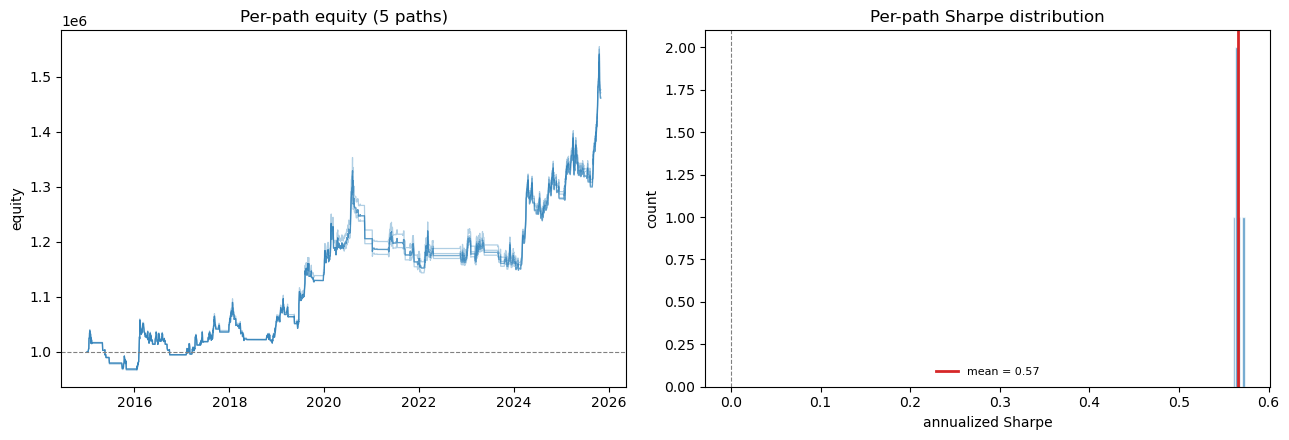

In [9]:
# Cell 9 — Stage 7: metrics on the CPCV multi-path result (skills/08-metrics.md).
# summary() = aggregate table + per-path equity overlay + Sharpe histogram
# (it calls aggregate_metrics/metrics_per_path internally — single entry point).
# PSR here is single-trial evidence; DSR deflation is Stage 9, NOT this cell.
agg = mp_res.summary()

per_path = mp_res.metrics_per_path()
pp = pd.DataFrame({
    f"path_{i}": {
        "sharpe": r.sharpe,
        "sortino": r.sortino,
        "psr": r.psr,
        "max_dd": r.max_drawdown,
        "ann_return": r.ann_return,
        "ann_vol": r.ann_vol,
        "min_trl_bars": r.min_trl,
        "n_obs": r.n_obs,
    }
    for i, r in enumerate(per_path)
}).T

print("\nPer-path metrics:")
print(pp.to_string(float_format=lambda v: f"{v:,.3f}"))
print(f"\nSharpe across {mp_res.n_paths} paths: mean={agg['sharpe_mean']:.3f} "
      f"std={agg['sharpe_std']:.3f} min={agg['sharpe_min']:.3f} max={agg['sharpe_max']:.3f}")
print(f"PSR(0) across paths:    mean={agg['psr_mean']:.3f} min={agg['psr_min']:.3f}")
print(f"MaxDD across paths:     mean={agg['max_drawdown_mean']:.2%} worst={agg['max_drawdown_max']:.2%}")
powered = all(r.min_trl < r.n_obs for r in per_path if pd.notna(r.min_trl))
print(f"MinTRL vs sample:       all paths powered = {powered}")

In [10]:
# Cell 10 — Stage 9: Deflated Sharpe Ratio (skills/09-selection.md).
# K = 2 distinct configs evaluated OOS this session: full-Kelly (Cells 4-5) and
# vol_only paper-vol (Cells 6, 8-9; the reported one). CPCV paths are NOT trials
# (one trial measured 5 ways); in-train λ grid search is NOT a trial (in-sample).
# Default asymptotic per-trial SR variance (LdP 2014 recipe, no registry yet).
from backtest.selection import dsr, expected_max_sr
from backtest.metrics.core import sharpe_var_term

K = 2

deflated = {c: dsr(mp_res.path_returns[c].dropna(), K=K)
            for c in mp_res.path_returns.columns}

# Luck-max threshold (annualized) per path, for display
rows = []
for c in mp_res.path_returns.columns:
    r = mp_res.path_returns[c].dropna().to_numpy()
    T = len(r)
    sr_pb = r.mean() / r.std(ddof=1)
    var_term = sharpe_var_term(r, sr_pb)
    luck_ann = expected_max_sr(K, var_term / T) * np.sqrt(P["tdays"])
    rows.append({"path": c, "sharpe_ann": sr_pb * np.sqrt(P["tdays"]),
                 "luck_max_ann": luck_ann, "psr": per_path[int(c[-1])].psr,
                 "dsr": deflated[c]})
dsr_df = pd.DataFrame(rows).set_index("path")

print(f"Trials K = {K} (full-Kelly config + vol_only config, this session)")
print(dsr_df.to_string(float_format=lambda v: f"{v:.4f}"))
vals = list(deflated.values())
print(f"\nDSR across {mp_res.n_paths} paths: median={np.median(vals):.4f} "
      f"min={np.min(vals):.4f} max={np.max(vals):.4f}")
print(f"Sanity: DSR < PSR on every path (K>1 deflation): "
      f"{all(dsr_df.loc[c, 'dsr'] < dsr_df.loc[c, 'psr'] for c in dsr_df.index)}")
print(f"Realized Sharpe beats luck-max on every path: "
      f"{bool((dsr_df.sharpe_ann > dsr_df.luck_max_ann).all())}")

Trials K = 2 (full-Kelly config + vol_only config, this session)
        sharpe_ann  luck_max_ann    psr    dsr
path                                          
path_0      0.5640        0.1567 0.9693 0.9116
path_1      0.5643        0.1567 0.9694 0.9118
path_2      0.5657        0.1567 0.9697 0.9125
path_3      0.5732        0.1567 0.9713 0.9164
path_4      0.5600        0.1566 0.9684 0.9097

DSR across 5 paths: median=0.9118 min=0.9097 max=0.9164
Sanity: DSR < PSR on every path (K>1 deflation): True
Realized Sharpe beats luck-max on every path: True


In [11]:
# Cell 11 — Stage 10: trial registry (skills/11-registry.md).
# Log the K=2 committed trials (full-Kelly, vol_only) under one family with ONE
# shared evaluation procedure: single-path, fit once 2005-2014, test 2015-2025-10-31
# (reg.run is the canonical entry; family must not mix WF/CPCV procedures).
# Causal graph: diagrams/forecast_to_fill_gold_causal.png (spec Sec 14.1 hypothesis).
# NOTE: do NOT re-run this cell — each execution logs new trials and inflates K.
from backtest.registry import TrialRegistry

reg = TrialRegistry("./trial_store")
FAMILY = "forecast_to_fill_gold"
GRAPH = "diagrams/forecast_to_fill_gold_causal.png"

train_dates_reg = panel.dates[(panel.dates >= "2005-01-01") & (panel.dates <= "2014-12-31")]
test_dates_reg = panel.dates[(panel.dates >= "2015-01-01") & (panel.dates <= "2025-10-31")]

logged = {}
for name, make in [("full_kelly", ForecastToFillGoldStrategy), ("vol_only", _make_strat)]:
    eng = Engine(panel, make(), costs=costs, liquidity=liq, initial_capital=1_000_000)
    res = reg.run(eng, causal_graph_path=GRAPH, family=FAMILY,
                  train_dates=train_dates_reg, test_dates=test_dates_reg)
    r = res.returns.dropna()
    logged[name] = r.mean() / r.std() * np.sqrt(P["tdays"]) if r.std() > 0 else float("nan")

trials = reg.list(family=FAMILY, include_exploratory=False)
K_count = reg.k(family=FAMILY, method="count")
K_eff = reg.k(family=FAMILY, method="effective", threshold=0.5)
dsr_last = reg.dsr_for(trials[-1]["id"], family=FAMILY, method="effective", threshold=0.5)

print(f"Family: {FAMILY} | store: {reg.directory}")
for nm, sh in logged.items():
    print(f"  logged {nm:11s} single-path OOS Sharpe {sh:+.3f}")
print(f"Trials in family:  {len(trials)}")
print(f"K (count):         {K_count} | K (effective@0.5): {K_eff}")
print(f"DSR of last trial (vol_only, K_eff from registry): {dsr_last:.4f}")
for t in trials:
    print(f"  id={t['id']} hash={t['strategy_hash']} exploratory={t['exploratory']} "
          f"sharpe={t['sharpe']:+.3f} psr={t['psr']:.3f} "
          f"test={t['test_start'][:10]} -> {t['test_end'][:10]}")

Family: forecast_to_fill_gold | store: trial_store
  logged full_kelly  single-path OOS Sharpe +0.569
  logged vol_only    single-path OOS Sharpe +0.561
Trials in family:  2
K (count):         2 | K (effective@0.5): 1
DSR of last trial (vol_only, K_eff from registry): 0.9688
  id=9 hash=e099627d2e8ddb17 exploratory=0 sharpe=+0.569 psr=0.971 test=2015-01-01 -> 2025-10-31
  id=10 hash=6e70c59b87ab0f1b exploratory=0 sharpe=+0.561 psr=0.969 test=2015-01-01 -> 2025-10-31


In [13]:
# Cell 12 — Stage 8: Monte Carlo stress test (skills/10-simulation.md §15.1).
# Generators fit on real OOS GC returns (2015 -> 2025-10): gaussian (drift baseline),
# block_bootstrap (practical default), permutation (lookahead-leak null — mandatory).
# Surfaced mismatches: synthetic paths are close-only (no OHLC/volume), so this MC
# variant feeds hi=lo=close -> TR collapses to |dC| (Wilder close-only fallback,
# tighter stops than true ATR); costs = Commission only (MarketImpact needs volume;
# impact was ~0.01bp on real data). Strategy pre-fit on real 2005-2014 (MC engine
# does not call fit; deep copies carry frozen train stats). vol_only @ paper caps.
from backtest.simulation import (
    MonteCarloEngine, GaussianGenerator, BlockBootstrapGenerator,
    PermutationGenerator, GeneratorValidator,
)


class ForecastToFillGoldMC(ForecastToFillGoldStrategy):
    """Close-only MC variant: prices-only requirement; hi=lo=close so TR=|dC|."""

    def required_data(self) -> dict:
        return {"prices": None}

    def _raw_target(self, data, t: pd.Timestamp) -> float:
        if not self._fitted:
            return 0.0
        idx = data.prices.index
        if t not in idx:
            return 0.0
        i = idx.get_loc(t)
        if i < max(P["K"], P["atr_n"], 20):
            return 0.0
        px = data.prices[ASSET].iloc[: i + 1].to_numpy()
        sig = _signals(px, px, px, self._lam, self._mu_tr, self._sig_tr, self._sigma2_0)
        j = -1
        c, atr = px[j], sig["atr"][j]
        p_bull, p_bear, dy = sig["p_bull"][j], sig["p_bear"][j], sig["dy"][j]
        w_conf, w_vol = sig["w_conf"][j], sig["w_vol"][j]
        f = _kelly_f(self._mu_k, self._sigma2_k, P["cost_rt"], P["eta"], P["n_rt"], P["kelly_frac"])
        if self._vol_only:
            target = min(P["w_max"], w_conf)
        else:
            if f < 1e-8:
                f = P["baseline_frac"] * w_vol
            target = min(P["w_max"], f * w_conf)
        if self._in_trade:
            self._trade_age += 1
            self._peak_px = max(self._peak_px, c)
            exit_now = False
            if np.isfinite(atr):
                if c < self._entry_px - P["hard_atr"] * atr:
                    exit_now = True
                elif c < self._peak_px - P["trail_atr"] * atr:
                    exit_now = True
            if self._trade_age >= P["max_age"]:
                exit_now = True
            if p_bear > P["pbear_close"]:
                exit_now = True
                target = 0.0
            elif p_bear > P["pbear_halve"]:
                target *= 0.5
            if exit_now:
                self._in_trade = False
                self._trade_age = 0
                target = 0.0
        else:
            if (p_bull >= P["pbull_act"]) and (dy > 0) and target > 0:
                self._in_trade = True
                self._entry_px = self._peak_px = c
                self._trade_age = 0
            else:
                target = 0.0
        return float(max(0.0, target))


# 1. Real OOS returns the generators must mimic (single asset, shape (T, 1)).
r_real = prices[ASSET].loc[eval_dates].pct_change().dropna().to_numpy().reshape(-1, 1)
gens = {
    "gaussian": GaussianGenerator.fit(r_real),
    "block_bootstrap": BlockBootstrapGenerator.fit(r_real),
    "permutation": PermutationGenerator(r_real),
}
print(f"Block length (fit): {gens['block_bootstrap'].block_length}")

# 2. Validate against the Cont-2001 stylized-fact gate.
validator = GeneratorValidator(r_real, n_paths=20, seed=0)
for name, gen in gens.items():
    vr = validator.validate(gen)
    failed = [m for m, p in vr.passed.items() if not p]
    print(f"  {name:16s} overall_passed={vr.overall_passed}  failed={failed}")

# 3. Pre-fit prototype on real data (MC workers deep-copy; fit is NOT re-called).
proto = ForecastToFillGoldMC(max_position=P["w_max"], max_gross=P["w_max"],
                             max_net=P["w_max"], vol_only=True)
proto.fit(panel.as_of(pd.Timestamp("2014-12-31")))
print(f"Prototype fit: lam={proto._lam:.3f} (frozen real-data train stats)")

# 4. Run: 200 paths x 3 generators, costs on (commission leg).
mc = MonteCarloEngine(
    strategy=proto,
    generators=gens,
    assets=list(panel.assets_all),
    dates=eval_dates[1:],  # permutation caps n_steps at T=len(r_real)
    costs=Commission(bps=LEG_BPS),
    initial_capital=1_000_000,
    warmup_bars=60,
).run(n_paths=200, seed=0, n_jobs=-1)

tbl = mc.summary()

perm_sharpes = [r.sharpe for r in mc.metrics_per_path()["permutation"] if np.isfinite(r.sharpe)]
bb_q05 = tbl.loc["block_bootstrap", "sharpe_q05"]
print(f"\nLeak check — permutation-null median Sharpe: {np.median(perm_sharpes):+.3f} "
      f"(|x| >> 0 would mean lookahead)")
print(f"Robustness — block_bootstrap sharpe_q05: {bb_q05:+.3f}")

Block length (fit): 2
  gaussian         overall_passed=False  failed=['kurt_ratio', 'ks_pvalue', 'hill_tail_diff', 'ljung_box_r2_pvalue']
  block_bootstrap  overall_passed=False  failed=['ljung_box_r2_pvalue']
  permutation      overall_passed=False  failed=['ljung_box_r2_pvalue']
Prototype fit: lam=0.880 (frozen real-data train stats)


Monte Carlo summary: 200 paths × 3 generators (gaussian, block_bootstrap, permutation)
                 sharpe_mean  sharpe_q05  sharpe_q50  sharpe_q95  sortino_mean  sortino_q05  sortino_q50  sortino_q95  max_drawdown_mean  max_drawdown_q05  max_drawdown_q50  max_drawdown_q95  psr_mean  psr_q05  psr_q50  psr_q95
generator                                                                                                                                                                                                                          
gaussian              0.5098      0.0360      0.5170      1.0028        0.4138       0.0274       0.4238       0.8477             0.1201            0.0714            0.1155            0.1931    0.8856   0.5475   0.9569   0.9996
block_bootstrap       0.4783      0.0199      0.4769      0.9309        0.3835       0.0145       0.3802       0.7771             0.1252            0.0750            0.1176            0.1893    0.8649   0.5262   0.9428   0.9989
p


Leak check — permutation-null median Sharpe: +0.464 (|x| >> 0 would mean lookahead)
Robustness — block_bootstrap sharpe_q05: +0.020


In [4]:
# Cell 13 — EXPLORATORY: leverage-to-budget variant (lev = 15% / 6.37% realized).
# Cell 6 showed the 15% vol budget is never realized (flat ~76% of days -> 6.37% ann vol).
# This scales the vol_only target by lev, re-capped at paper W_max=2.0, so in-trade
# sizing spends the budget. Cap binds when unlevered w_conf > W_max/lev = 0.85
# (Cell 6 peak was 1.37), so realized vol will land below 15%. Same 22-fold WF as
# Cell 6. New trial for the registry (exploratory) — do NOT treat as the headline run.
# Self-contained: redefines WF constants so it runs on a fresh kernel with only Cells 1-3.
from backtest.engine import Engine
from backtest.metrics import compute_metrics

OOS_START = pd.Timestamp("2015-01-01")
OOS_END = pd.Timestamp("2025-10-31")
TRAIN_YEARS = 10
TEST_MONTHS = 6
CAPITAL = 1_000_000
fold_months = pd.date_range(OOS_START, OOS_END, freq="6MS")
LEV = 0.15 / 0.0637  # ~2.35


class LeveredForecastToFillGold(ForecastToFillGoldStrategy):
    """vol_only sizing scaled by lev, re-capped at paper W_max. All else identical."""

    def __init__(self, lev: float, **kw):
        super().__init__(**kw)
        self._lev = lev

    def _raw_target(self, data, t: pd.Timestamp) -> float:
        base = super()._raw_target(data, t)  # parent cap never binds: w_conf <= w_vol <= W_max
        return float(min(P["w_max"], self._lev * base))


def _make_strat13():
    return LeveredForecastToFillGold(
        lev=LEV,
        max_position=P["w_max"],
        max_gross=P["w_max"],
        max_net=P["w_max"],
        vol_only=True,
    )


stitched13: dict = {}
fold_rows13 = []
costs13 = 0.0
cap_days = 0
active_days = 0

for i, month in enumerate(fold_months):
    pos = panel.dates.searchsorted(month, side="left")
    if pos >= len(panel.dates):
        break
    ts = panel.dates[pos]
    if ts > OOS_END:
        break
    prior = panel.dates[panel.dates < ts]
    if len(prior) == 0:
        continue
    train_end = prior[-1]
    train_start = train_end - pd.DateOffset(years=TRAIN_YEARS)
    train_dates = panel.dates[(panel.dates >= train_start) & (panel.dates <= train_end)]
    test_end = min(ts + pd.DateOffset(months=TEST_MONTHS), OOS_END)
    test_dates = panel.dates[(panel.dates >= ts) & (panel.dates <= test_end)]
    if len(train_dates) < 252 * 5 or len(test_dates) < 10:
        continue

    eng = Engine(panel, _make_strat13(), costs=costs, liquidity=liq, initial_capital=CAPITAL)
    res = eng.run(train_dates=train_dates, test_dates=test_dates)
    costs13 += float(res.costs.sum())
    w = res.weights[ASSET].abs()
    cap_days += int((w > P["w_max"] - 1e-6).sum())
    active_days += int((w > 1e-4).sum())
    r = res.returns.dropna()
    for t, v in r.items():
        stitched13[t] = v
    fold_rows13.append({
        "test_start": ts.date(),
        "net_ret": float((1 + r).prod() - 1),
        "max_w": float(w.max()),
        "unfilled": float(res.unfilled.abs().sum().sum()),
    })
    if (i + 1) % 4 == 0:
        print(f"  {i + 1}/{len(fold_months)} folds through {ts.date()} ...")

wf13_ret = pd.Series(stitched13, name="return").sort_index()
wf13_ret = wf13_ret[(wf13_ret.index >= OOS_START) & (wf13_ret.index <= OOS_END)]
wf13_eq = (1.0 + wf13_ret).cumprod() * CAPITAL
bm13 = benchmark.reindex(wf13_ret.index).pct_change().fillna(0.0)
wf13_metrics = compute_metrics(wf13_ret, wf13_eq, benchmark=bm13)

fold_df13 = pd.DataFrame(fold_rows13)
print(f"Mode: levered vol_only  lev={LEV:.2f}  cap=W_max={P['w_max']}")
print(f"Folds: {len(fold_df13)} | OOS bars: {len(wf13_ret)} | total costs: ${costs13:,.0f}")
print(f"Sharpe: {wf13_metrics.sharpe:+.2f} | Sortino: {wf13_metrics.sortino:+.2f} | "
      f"Calmar: {wf13_metrics.calmar:+.2f}")
print(f"Ann return: {wf13_metrics.ann_return:.2%} | ann vol: {wf13_metrics.ann_vol:.2%} | "
      f"maxDD: {wf13_metrics.max_drawdown:.2%}")
print(f"Hit rate: {wf13_metrics.hit_rate:.1%} | IR vs XAUUSD: {wf13_metrics.information_ratio:+.2f} | "
      f"beta: {wf13_metrics.beta:+.3f}")
print(f"Cap-bound days: {cap_days}/{active_days} active ({cap_days / max(active_days, 1):.0%}) | "
      f"max |w|: {fold_df13.max_w.max():.2%}")
print(f"Unfilled notional: ${fold_df13.unfilled.sum():,.0f}")
print(f"Final equity: ${wf13_eq.iloc[-1]:,.0f} (P&L {wf13_eq.iloc[-1] / CAPITAL - 1:+.2%})")
# Cell 6 reference (stored run: Sharpe +0.55, ann ret 3.47%, vol 6.37%, maxDD 13.31%)
print(f"\nvs Cell 6 (unlevered): Sharpe +0.55 -> {wf13_metrics.sharpe:+.2f} | "
      f"ann ret 3.47% -> {wf13_metrics.ann_return:.2%} | "
      f"vol 6.37% -> {wf13_metrics.ann_vol:.2%} | "
      f"maxDD 13.31% -> {wf13_metrics.max_drawdown:.2%}")
wf13_eq.tail(3)


  4/22 folds through 2016-07-01 ...


  8/22 folds through 2018-07-02 ...


  12/22 folds through 2020-07-01 ...


  16/22 folds through 2022-07-01 ...


  20/22 folds through 2024-07-01 ...


Mode: levered vol_only  lev=2.35  cap=W_max=2.0
Folds: 22 | OOS bars: 2820 | total costs: $34,439
Sharpe: +0.52 | Sortino: +0.39 | Calmar: +0.26
Ann return: 7.03% | ann vol: 14.58% | maxDD: 29.40%
Hit rate: 24.8% | IR vs XAUUSD: -0.33 | beta: +0.612
Cap-bound days: 150/1366 active (11%) | max |w|: 200.04%
Unfilled notional: $70,496,923
Final equity: $2,086,194 (P&L +108.62%)

vs Cell 6 (unlevered): Sharpe +0.55 -> +0.52 | ann ret 3.47% -> 7.03% | vol 6.37% -> 14.58% | maxDD 13.31% -> 29.40%


2025-10-29    2.087183e+06
2025-10-30    2.088256e+06
2025-10-31    2.086194e+06
Name: return, dtype: float64

In [5]:
# Cell 14 — EXPLORATORY: 2011-2015 gold bear-window diagnostic (not a selection trial).
# Question: does the trend overlay protect capital when the drift disappears?
# Same WF scheme as Cells 6/13 (6m non-overlapping folds, refit each fold), but:
#   MISMATCH 1: data starts 2005 -> early folds train on ~6y, not the spec's 10y.
#   MISMATCH 2: 2015 overlaps the headline OOS window -> diagnostic only, K unaffected.
# Runs both scales (unlevered vol_only + lev=2.35) and buy-and-hold on identical dates.
BEAR_START = pd.Timestamp("2011-01-01")
BEAR_END = pd.Timestamp("2015-12-31")
bear_months = pd.date_range(BEAR_START, BEAR_END, freq="6MS")


def _make_strat14():  # Cell 6's unlevered vol_only config (Cell 6 not loaded in this kernel)
    return ForecastToFillGoldStrategy(
        max_position=P["w_max"], max_gross=P["w_max"], max_net=P["w_max"], vol_only=True,
    )


runs14 = {"unlevered": _make_strat14, "levered": _make_strat13}
stitched14: dict = {name: {} for name in runs14}
costs14 = {name: 0.0 for name in runs14}
train_spans = []

for i, month in enumerate(bear_months):
    pos = panel.dates.searchsorted(month, side="left")
    if pos >= len(panel.dates):
        break
    ts = panel.dates[pos]
    if ts > BEAR_END:
        break
    prior = panel.dates[panel.dates < ts]
    if len(prior) == 0:
        continue
    train_end = prior[-1]
    train_start = train_end - pd.DateOffset(years=TRAIN_YEARS)
    train_dates = panel.dates[(panel.dates >= train_start) & (panel.dates <= train_end)]
    test_end = min(ts + pd.DateOffset(months=TEST_MONTHS), BEAR_END)
    test_dates = panel.dates[(panel.dates >= ts) & (panel.dates <= test_end)]
    if len(train_dates) < 252 * 5 or len(test_dates) < 10:
        continue
    train_spans.append(len(train_dates) / 252)

    for name, maker in runs14.items():
        eng = Engine(panel, maker(), costs=costs, liquidity=liq, initial_capital=CAPITAL)
        res = eng.run(train_dates=train_dates, test_dates=test_dates)
        costs14[name] += float(res.costs.sum())
        for t, v in res.returns.dropna().items():
            stitched14[name][t] = v
    print(f"  fold {i + 1}/{len(bear_months)} {ts.date()} (train {train_spans[-1]:.1f}y) done")

print(f"\nBear window 2011-01 -> 2015-12 | train spans {min(train_spans):.1f}y-{max(train_spans):.1f}y "
      f"(spec wants 10y; data starts 2005)")

rows14 = []
ret14 = {}
for name in runs14:
    r = pd.Series(stitched14[name], name="return").sort_index()
    r = r[(r.index >= BEAR_START) & (r.index <= BEAR_END)]
    ret14[name] = r
    eq = (1.0 + r).cumprod() * CAPITAL
    bmr = benchmark.reindex(r.index).pct_change().fillna(0.0)
    m = compute_metrics(r, eq, benchmark=bmr)
    active = float((r.abs() > 1e-6).mean())
    rows14.append({
        "run": name, "ann_ret": m.ann_return, "ann_vol": m.ann_vol, "sharpe": m.sharpe,
        "maxDD": m.max_drawdown, "total": eq.iloc[-1] / CAPITAL - 1,
        "costs": costs14[name], "active_days": active,
    })

# Buy-and-hold spot gold on the identical stitched dates
bh = benchmark.reindex(ret14["unlevered"].index).pct_change().fillna(0.0)
bh_eq = (1.0 + bh).cumprod() * CAPITAL
bh_m = compute_metrics(bh, bh_eq)
rows14.append({
    "run": "buy_hold_XAUUSD", "ann_ret": bh_m.ann_return, "ann_vol": bh_m.ann_vol,
    "sharpe": bh_m.sharpe, "maxDD": bh_m.max_drawdown, "total": bh_eq.iloc[-1] / CAPITAL - 1,
    "costs": 0.0, "active_days": 1.0,
})

df14 = pd.DataFrame(rows14).set_index("run")
with pd.option_context("display.float_format", "{:.4f}".format):
    print(df14.to_string(formatters={
        "ann_ret": "{:+.2%}".format, "ann_vol": "{:.2%}".format, "sharpe": "{:+.2f}".format,
        "maxDD": "{:.2%}".format, "total": "{:+.2%}".format, "costs": "${:,.0f}".format,
        "active_days": "{:.1%}".format,
    }))

print(f"\nGold over window: {benchmark.reindex(ret14['unlevered'].index).iloc[0]:,.0f} -> "
      f"{benchmark.reindex(ret14['unlevered'].index).dropna().iloc[-1]:,.0f}")


  fold 1/10 2011-01-03 (train 6.2y) done


  fold 2/10 2011-07-01 (train 6.7y) done


  fold 3/10 2012-01-02 (train 7.2y) done


  fold 4/10 2012-07-02 (train 7.8y) done


  fold 5/10 2013-01-01 (train 8.3y) done


  fold 6/10 2013-07-01 (train 8.8y) done


  fold 7/10 2014-01-01 (train 9.3y) done


  fold 8/10 2014-07-01 (train 9.8y) done


  fold 9/10 2015-01-01 (train 10.3y) done


  fold 10/10 2015-07-01 (train 10.4y) done

Bear window 2011-01 -> 2015-12 | train spans 6.2y-10.4y (spec wants 10y; data starts 2005)
                ann_ret ann_vol sharpe  maxDD   total   costs active_days
run                                                                      
unlevered        +0.94%   4.58%  +0.22  7.78%  +4.79%  $4,027       30.9%
levered          +1.99%  10.72%  +0.23 17.67% +10.30% $10,370       31.5%
buy_hold_XAUUSD  -5.19%  16.95%  -0.22 44.85% -23.35%      $0      100.0%

Gold over window: 1,384 -> 1,061
